In [137]:
#from google.colab import drive
#drive.mount('/content/drive')

In [138]:
import sys
#sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [139]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [140]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [141]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (144987896052)>


In [ ]:
#
# Model with 9-4-quad-UP element and PDMY03 material
# By: Arash Khosravifar   January 2009
# Last edit:              August 2018
#

ops.wipe()
# There is no 'wipe all' in OpenSeesPy, ops.wipe() is sufficient.
startT = time.time()

######################### MAIN USER INPUTS #################################
matTag = 5  # 1 for (N1)60=35, 2 for (N1)60=25, 3 for (N1)60=15 and 4 for (N1)60=5 , 5 for Custom
vertPress = 1.0 * 100  # kPa vertical confining pressure
loadbias = 0.3  # Alpha = tau_xy/s'vo
Analysis_case = "undrained_monotonic"
# Options:
# undrained_cyclic
# undrained_monotonic: define target max shear strain
# drained_cyclic: applies 2 cycles for each strain (9 shear strain ranging from 0.0003% to 3%) for the purpose of G/Gmax and Damping curves
# drained_monotonic: define target max shear strain
######################### END OF MAIN USER INPUTS ###########################

# Load material properties from an external file
# In Python, this is done by importing the module or executing the script.
# Assuming the TCL file is converted to a Python file named DSS_material_properties.py
try:
    exec(open('DSS_material_properties.py').read())
except FileNotFoundError:
    print("Error: The file DSS_material_properties.py was not found.")
    exit()

# Some variables for the ELEMENT
fluidDen = 1.0  # Fluid mass density
waterbulk = 2.2e6  # kPa
kdrain = 1.0e1  # permeability for drained loading
kundrain = 1.0e-8  # permeability for undrained loading
gravY = 0.0
gravX = 0.0

# Some loading related variables
if Analysis_case == "undrained_cyclic":
    target_shear_strain = 3.0 / 100.0
    csr = 0.45
    period = 1.0
    deltaT = 0.005
    kPerm = kundrain
elif Analysis_case == "undrained_monotonic":
    target_shear_strain = 3.0 / 100.0
    period = 1.0
    deltaT = 0.005
    numSteps = 200
    kPerm = kundrain
    # also change penalty from 1e15 and 1e5 for sand to clay
elif Analysis_case == "drained_monotonic":
    # also change the damping to 0.005
    target_shear_strain = 1.0 / 100.0  # unit in strain - it will be multiplied by ySize later. Note: DON'T forget the ".0" in 1.0
    period = 1.0
    deltaT = 0.005
    numSteps = 3000
    kPerm = kdrain
    phaseTransAng = frinctionAng
    contraction_a = 0.0
    contraction_b = 0.0
    contraction_c = 0.0
    contraction_d = 0.0
    contraction_e = 0.0
    dilation_a = 0.0
    dilation_b = 0.0
    dilation_c = 0.0
    liqParam1 = 0.0
    liqParam2 = 0.0
elif Analysis_case == "drained_cyclic":
    period = 10.0
    deltaT = 0.005
    numSteps = 4000
    kPerm = kdrain
    phaseTransAng = frinctionAng
    contraction_a = 0.0
    contraction_b = 0.0
    contraction_c = 0.0
    contraction_d = 0.0
    contraction_e = 0.0
    dilation_a = 0.0
    dilation_b = 0.0
    dilation_c = 0.0
    liqParam1 = 0.0
    liqParam2 = 0.0

# Define Rayleigh Damping
rayleigh_damping1 = 0.001
rayleigh_damping2 = 0.001
rayleigh_w1 = 2 * math.pi / period
rayleigh_w2 = 2 * math.pi / (period / 2.0)
Kinitproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (-1.0 * rayleigh_damping1 / rayleigh_w1 + 1.0 * rayleigh_damping2 / rayleigh_w2)
Mproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (rayleigh_damping1 * rayleigh_w1 - rayleigh_damping2 * rayleigh_w2)

####################################################################
xsize = 0.1
ysize = 0.1
thickness = 0.1

# define the 3DOF nodes
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.node(1, 0.0, 0.0)
ops.node(2, xsize, 0.0)
ops.node(3, xsize, ysize)
ops.node(4, 0.0, ysize)

ops.fix(1, 1, 1, 0)
ops.fix(2, 1, 1, 0)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(1, 2, 3)
ops.equalDOF(3, 4, 1, 2)

# define the 2DOF nodes
ops.model('basic', '-ndm', 2, '-ndf', 2)
ops.node(5, xsize / 2, 0.0)
ops.node(6, xsize, ysize / 2)
ops.node(7, xsize / 2, ysize)
ops.node(8, 0.0, ysize / 2)
ops.node(9, xsize / 2, ysize / 2)

ops.fix(5, 1, 1)
ops.equalDOF(3, 7, 1, 2)
ops.equalDOF(6, 8, 1, 2)
# ops.equalDOF(6, 9, 1, 2)

################# define material ##################################
ops.nDMaterial('PressureDependMultiYield03', matTag, 2, massDen, refG, refB, frinctionAng,
               peakShearStrain, refPress, pressDependCoe, phaseTransAng,
               0, contraction_a, contraction_b, contraction_c, contraction_d, contraction_e,
               dilation_a, dilation_b, dilation_c,
               noYieldSurf, liqParam1, liqParam2,
               pa, S0)

####################################################################
# define the element                     thick       maTag  bulk         fmass      hPerm   vPerm
ops.element('9_4_QuadUP', 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, thickness, matTag, waterbulk / 0.4, fluidDen, kPerm, kPerm, gravX, gravY)

####################################################################
# Recorders
if not os.path.exists("output"):
    os.mkdir("output")

ops.recorder('Node', '-file', f"output/disp1_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8, 9, '-dof', 1, 'disp')
ops.recorder('Node', '-file', f"output/disp2_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8, 9, '-dof', 2, 'disp')
ops.recorder('Node', '-file', f"output/pwp_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, '-dof', 3, 'vel')
ops.recorder('Element', '-file', f"output/stress_{Analysis_case}.out", '-time', '-ele', 1, 'material', 9, 'stress')  # s11 s22 s33 s12 eta (EFFECTIVE stresses)
ops.recorder('Element', '-file', f"output/strain_{Analysis_case}.out", '-time', '-ele', 1, 'material', 9, 'strain')  # e11 e22 gama12 (it is not e33 nor e12)
ops.recorder('Element', '-file', f"output/backbone_{Analysis_case}.out", '-ele', 1, 'material', 9, 'backbone', 100, 1600)

####################################################################
# GRAVITY APPLICATION (elastic behavior)
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, loadbias * vertPress * xsize * thickness * 0.25, -vertPress * xsize * thickness * 0.25, 0)
ops.load(4, loadbias * vertPress * xsize * thickness * 0.25, -vertPress * xsize * thickness * 0.25, 0)

ops.model('basic', '-ndm', 2, '-ndf', 2)
ops.timeSeries('Constant', 2)
ops.pattern('Plain', 2, 2)
ops.load(7, loadbias * vertPress * xsize * thickness * 0.5, -vertPress * xsize * thickness * 0.5)

ops.numberer('RCM')
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.0e-5, 50, 2)
ops.constraints('Plain')  # Penalty 1.e18 1.e18
ops.rayleigh(1.0 * Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
gama = 1.5
betta = (gama + 0.5)**2 / 4
ops.integrator('Newmark', gama, betta)
ops.algorithm('KrylovNewton')
ops.analysis('VariableTransient')

ops.updateMaterialStage('-material', 1, '-stage', 0)
ops.updateMaterialStage('-material', 2, '-stage', 0)
ops.updateMaterialStage('-material', 3, '-stage', 0)
ops.updateMaterialStage('-material', 4, '-stage', 0)
for i in range(1, 101):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
for i in range(1, 101):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
print("Done Elastic")
ops.updateMaterialStage('-material', 1, '-stage', 1)
ops.updateMaterialStage('-material', 2, '-stage', 1)
ops.updateMaterialStage('-material', 3, '-stage', 1)
ops.updateMaterialStage('-material', 4, '-stage', 1)
for i in range(1, 101):
    ops.analyze(1, 100)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")

for i in range(1, 201):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
print("Done Plastic")
print("Gravity Done!")

####################################################################
# Adjust some fixities for shear loading
# remove surface pwp fixity
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.remove('sp', 3, 3)
ops.remove('sp', 4, 3)
ops.equalDOF(3, 4, 3)

####################################################################
ops.loadConst('-time', 0.0)
ops.wipeAnalysis()

####################################################################
# NOW APPLY LOADING SEQUENCE AND ANALYZE (plastic)
# Load control cyclic
if Analysis_case == "undrained_cyclic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('ProfileSPD')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Plain')
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.timeSeries('Sine',4, 0, period * 1000, period)
    ops.pattern('Plain', 4, 4)
    ops.load(3, csr * vertPress * xsize * thickness * 0.25, 0, 0)
    ops.load(4, csr * vertPress * xsize * thickness * 0.25, 0, 0)
    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Sine',5, 0, period * 1000, period)
    ops.pattern('Plain', 5, 5)
    ops.load(7, csr * vertPress * xsize * thickness * 0.5, 0)

    print(Analysis_case)
    while abs(ops.nodeDisp(7, 1) / ysize) < target_shear_strain:
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        print(f"time = {ops.getTime()} sec")

# Disp control monotonic
elif Analysis_case == "undrained_monotonic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e10, 1.0e10)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Linear', 14)
    ops.pattern('Plain', 14, 14)
    ops.sp(3, 1, ysize * target_shear_strain)
    ops.sp(4, 1, ysize * target_shear_strain)
    ops.sp(7, 1, ysize * target_shear_strain)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")

# Disp control monotonic
elif Analysis_case == "drained_monotonic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e18, 1.0e18)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.timeSeries('Linear', 15)
    ops.pattern('Plain', 15, 15)
    ops.sp(3, 1, ysize * target_shear_strain)
    ops.sp(4, 1, ysize * target_shear_strain)
    ops.sp(7, 1, ysize * target_shear_strain)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")

# Disp control cyclic for G/Gmax and Xi curves
elif Analysis_case == "drained_cyclic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e18, 1.0e18)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Sine',4, 0, 1000, period)
    ops.pattern('Plain', 4, 4)
    ops.sp(3, 1, ysize * 0.0003 / 100.0)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 4)
    ops.loadConst()
    ops.timeSeries('Sine',5, 0, 1000, period)
    ops.pattern('Plain', 5, 5)
    ops.sp(3, 1, ysize * 0.001 / 100.0)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 5)
    ops.loadConst()
    ops.timeSeries('Sine', 6, 0, 1000, period)
    ops.pattern('Plain', 6, 6)
    ops.sp(3, 1, ysize * 0.003 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 6)
    ops.loadConst()
    ops.timeSeries('Sine',7, 0, 1000, period)
    ops.pattern('Plain', 7, 7)
    ops.sp(3, 1, ysize * 0.01 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 7)
    ops.loadConst()
    ops.timeSeries('Sine',8, 0, 1000, period)
    ops.pattern('Plain', 8, 8)
    ops.sp(3, 1, ysize * 0.03 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 8)
    ops.loadConst()
    ops.timeSeries('Sine',9, 0, 1000, period)
    ops.pattern('Plain', 9, 9)
    ops.sp(3, 1, ysize * 0.1 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 9)
    ops.loadConst()
    ops.timeSeries('Sine', 10, 0, 1000, period)
    ops.pattern('Plain', 10, 10)
    ops.sp(3, 1, ysize * 0.3 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 10)
    ops.loadConst()
    ops.timeSeries('Sine',11, 0, 1000, period)
    ops.pattern('Plain', 11, 11)
    ops.sp(3, 1, ysize * 1.0 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 11)
    ops.loadConst()
    ops.timeSeries('Sine',12, 0, 1000, period)
    ops.pattern('Plain', 12,12 )
    ops.sp(3, 1, ysize * 3.0 * 0.01)
    for i in range(1, int(numSteps * 1.25) + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
####################################################################
endT = time.time()
print(f"Execution time: {endT - startT} seconds.")
print("Finished with cyclic loading")
ops.wipe()
# The 'wipe all' and 'wipe' at the end are redundant since ops.wipe() clears everything.

time = 1000.0 sec
time = 2000.0 sec
time = 3000.0 sec
time = 4000.0 sec
time = 5000.0 sec
time = 6000.0 sec
time = 7000.0 sec
time = 8000.0 sec
time = 9000.0 sec
time = 10000.0 sec
time = 11000.0 sec
time = 12000.0 sec
time = 13000.0 sec
time = 14000.0 sec
time = 15000.0 sec
time = 16000.0 sec
time = 17000.0 sec
time = 18000.0 sec
time = 19000.0 sec
time = 20000.0 sec
time = 21000.0 sec
time = 22000.0 sec
time = 23000.0 sec
time = 24000.0 sec
time = 25000.0 sec
time = 26000.0 sec
time = 27000.0 sec
time = 28000.0 sec
time = 29000.0 sec
time = 30000.0 sec
time = 31000.0 sec
time = 32000.0 sec
time = 33000.0 sec
time = 34000.0 sec
time = 35000.0 sec
time = 36000.0 sec
time = 37000.0 sec
time = 38000.0 sec
time = 39000.0 sec
time = 40000.0 sec
time = 41000.0 sec
time = 42000.0 sec
time = 43000.0 sec
time = 44000.0 sec
time = 45000.0 sec
time = 46000.0 sec
time = 47000.0 sec
time = 48000.0 sec
time = 49000.0 sec
time = 50000.0 sec
time = 51000.0 sec
time = 52000.0 sec
time = 53000.0 sec
ti

CTestNormDispIncr::test() - iteration: 2 current Norm: 8.18065e-14 (max: 1e-05, Norm deltaR: 6.07037e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.06887e-15 (max: 1e-05, Norm deltaR: 4.91434e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.24836e-14 (max: 1e-05, Norm deltaR: 3.3884e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 7.08328e-15 (max: 1e-05, Norm deltaR: 6.47648e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 2.2918e-14 (max: 1e-05, Norm deltaR: 3.13155e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 6.246e-15 (max: 1e-05, Norm deltaR: 5.4722e-16)
CTestNormDispIncr::test() - iteration: 2 current Norm: 6.26954e-15 (max: 1e-05, Norm deltaR: 3.88869e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 3.54537e-06 (max: 1e-05, Norm deltaR: 4.80252e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.18189e-06 (max: 1e-05, Norm deltaR: 7.64966e-16)
CTestNormDispIncr::test() - iteration: 1 current No

time = 0.11696078431372552 sec
time = 0.12196078431372552 sec
time = 0.1269607843137255 sec
time = 0.13196078431372552 sec
time = 0.13696078431372552 sec
time = 0.14196078431372552 sec
time = 0.14696078431372553 sec
time = 0.15196078431372553 sec
time = 0.15696078431372554 sec
time = 0.16196078431372554 sec
time = 0.16696078431372555 sec
time = 0.17196078431372555 sec
time = 0.17696078431372556 sec
time = 0.18196078431372556 sec
time = 0.18696078431372556 sec
time = 0.19196078431372557 sec
time = 0.19696078431372557 sec
time = 0.20196078431372558 sec
time = 0.20696078431372558 sec
time = 0.2119607843137256 sec
time = 0.2169607843137256 sec
time = 0.2219607843137256 sec
time = 0.2269607843137256 sec
time = 0.2319607843137256 sec
time = 0.2369607843137256 sec
time = 0.2419607843137256 sec
time = 0.24696078431372562 sec
time = 0.2519607843137256 sec
time = 0.2569607843137256 sec
time = 0.2619607843137256 sec
time = 0.2669607843137256 sec
time = 0.2719607843137256 sec
time = 0.276960784313

after: 50 iterations  current Norm: 0.000144099 (max: 1e-05, Norm deltaR: 1.30826)
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()


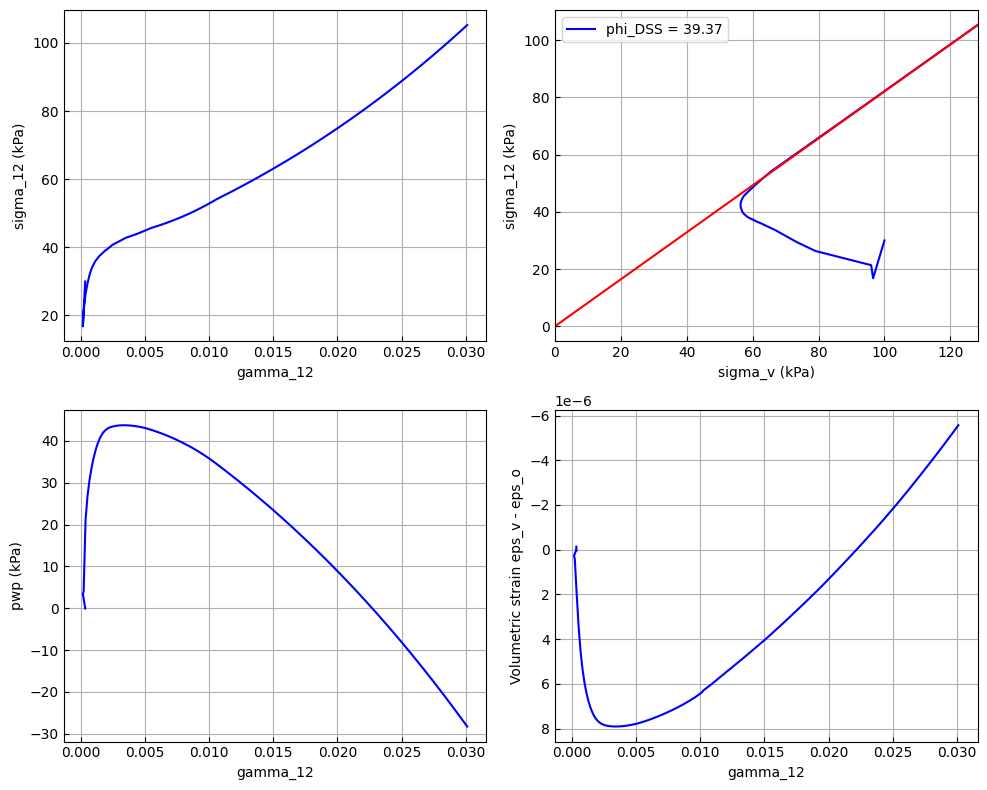

In [143]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
del min
# -----------------------------------------------------------------------------
# Post-processor converted and cleaned from MATLAB
# - Safe indexing (MATLAB->Python 1-based -> 0-based)
# - Avoids shadowing builtins (uses np.minimum/np.maximum)
# - Robust file loading with clear errors
# - Defensive index checks and fallbacks
# - Handles all four analysis cases
# -----------------------------------------------------------------------------

# -------------------------- Configuration ------------------------------------
# Options: 'undrained_cyclic', 'undrained_monotonic', 'drained_cyclic', 'drained_monotonic'
#Analysis_case = 'undrained_cyclic'
input_dir = Path('output')
consol_step = 500  # as in the MATLAB code (1-based). We'll compute 0-based index below.

# -------------------------- Helpers ------------------------------------------

def load_txt(path: Path) -> np.ndarray:
    """Load whitespace-delimited text file with numpy; give clear message on failure."""
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return np.loadtxt(path)


def safe_idx(arr: np.ndarray, idx: int, fallback: int = 0) -> int:
    """Return idx if in bounds else a fallback index (clamped)."""
    if idx < 0:
        return 0
    if idx >= arr.shape[0]:
        return arr.shape[0] - 1
    return idx

def idx_clamped(i: int, arr: np.ndarray) -> int:
    return int(np.clip(i, 0, arr.shape[0] - 1))

# -------------------------- Load data ---------------------------------------
try:
    input_disp1 = load_txt(input_dir / f'disp1_{Analysis_case}.out')
    input_disp2 = load_txt(input_dir / f'disp2_{Analysis_case}.out')
    input_stress = load_txt(input_dir / f'stress_{Analysis_case}.out')
    input_strain = load_txt(input_dir / f'strain_{Analysis_case}.out')
    input_pwp = load_txt(input_dir / f'pwp_{Analysis_case}.out')
    input_backbone = load_txt(input_dir / f'backbone_{Analysis_case}.out')
except Exception as e:
    print('Error loading files:', e)
    sys.exit(1)

# -------------------------- Preprocessing -----------------------------------
# Convert MATLAB 1-based consol_step to Python 0-based index
consol_i = consol_step - 1

# Displacements
Disp_1 = input_disp1[:, 1:]
Disp_2 = input_disp2[:, 1:]

# Stresses (compression:+, tension:-)
# NOTE: MATLAB used columns 2..6; numpy is 0-based -> columns 1..5
s_11 = -input_stress[:, 1]
s_22 = -input_stress[:, 2]
s_33 = -input_stress[:, 3]
s_12 = input_stress[:, 4]
# eta = input_stress[:, 5] if present
eta = input_stress[:, 5] if input_stress.shape[1] > 5 else None

# Octahedral shear stress
tau_oct = (1.0 / 3.0) * np.sqrt((s_11 - s_22) ** 2 + (s_11 - s_33) ** 2 + (s_22 - s_33) ** 2 + 6.0 * s_12 ** 2)
q = 3.0 / np.sqrt(2.0) * tau_oct

# PWP and mean stress
# pwp file assumed columns: time, pwp1, pwp2, pwp3, pwp4 (like MATLAB)
if input_pwp.shape[1] < 5:
    raise ValueError('pwp file must have at least 5 columns: time and 4 pwp measurements')

pwp = (input_pwp[:, 1] + input_pwp[:, 2] + input_pwp[:, 3] + input_pwp[:, 4]) / 4.0
p = (s_11 + s_22 + s_33) / 3.0
p_tot = p + pwp
time = input_pwp[:, 0]

# Strains
# input_strain assumed to have columns [time, e11, e22, gamma12, ...]
e_11 = -input_strain[:, 1]
e_22 = -input_strain[:, 2]
gama_12 = input_strain[:, 3]
e_33 = np.zeros_like(e_11)
e_v = e_11 + e_22 + e_33
gama_oct = (2.0 / 3.0) * np.sqrt((e_11 - e_22) ** 2 + (e_22 - e_33) ** 2 + (e_11 - e_33) ** 2 + 6.0 * (gama_12 / 2.0) ** 2)

# CSL and void ratio
cs1, cs2, cs3 = 0.9, 0.1, 1.0
void_i = 0.8
void = void_i - e_22 * (1.0 + void_i)

# counts
total_step = gama_12.shape[0]

# Ru computations (safe denominators)
ru_1 = pwp / np.maximum(p, 0.001)
ru_2 = pwp / p[safe_idx(p, consol_i)]
ru_3 = pwp / s_22[safe_idx(s_22, consol_i)]

# -------------------------- Utility safe indexing for time-series ----------
def idx_clamped(i: int, arr: np.ndarray) -> int:
    return max(0, min(i, arr.shape[0] - 1))

# small helper to fetch value with fallback

def val_at(arr: np.ndarray, i: int, fallback_i: int = None):
    if fallback_i is None:
        fallback_i = arr.shape[0] - 1
    ii = idx_clamped(i, arr)
    return arr[ii]

# -------------------------- Analysis cases ----------------------------------

if Analysis_case == 'drained_cyclic':
    period = 10.0
    cycle = time / period

    NoStepsCycle = 2000
    NoCycleEach = 2

    # MATLAB: corr_steps = [consol_step+NoStepsCycle/4:NoStepsCycle*NoCycleEach:consol_step+9*NoStepsCycle*NoCycleEach]
    start = consol_i + NoStepsCycle // 4
    end = consol_i + 9 * NoStepsCycle * NoCycleEach
    step = NoStepsCycle * NoCycleEach
    corr_steps = np.arange(start, end + 1, step, dtype=int)
    corr_steps = corr_steps[corr_steps < total_step]

    # Secant stiffness
    # Use safe indices; prefer consol_i+1 as MATLAB used consol_step+1 for Gmax
    gmax_idx = idx_clamped(consol_i + 1, gama_12)
    G_sec = s_12[corr_steps] / np.maximum(gama_12[corr_steps], 1e-18)
    G_max = s_12[gmax_idx] / np.maximum(gama_12[gmax_idx], 1e-18)
    G_max_oct = tau_oct[gmax_idx] / np.maximum(gama_oct[gmax_idx], 1e-18)

    # EPRI reference
    GratioEPRI6 = np.array([1, 0.98, 0.919, 0.751, 0.519, 0.271, 0.121, 0.045, 0.024])
    GratioEPRI76 = np.array([1, 0.999, 0.982, 0.9, 0.752, 0.502, 0.282, 0.124, 0.07])
    gama_EPRI = np.array([0.000003, 0.00001, 0.00003, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03])

    # compute gama_EPRI_oct using the strain values at consol_i (MATLAB used index 500)
    idx_500 = idx_clamped(consol_i, e_11)
    gama_EPRI_oct = (2.0 / 3.0) * np.sqrt((e_11[idx_500] - e_22[idx_500]) ** 2 + (e_22[idx_500] - e_33[idx_500]) ** 2 + (e_11[idx_500] - e_33[idx_500]) ** 2 + 6.0 * (gama_EPRI / 2.0) ** 2)

    # Xi (damping ratio) computed by numerical trapezoid over strain vs stress for each cycle window
    Xi = np.zeros_like(corr_steps, dtype=float)
    for k, start_idx in enumerate(corr_steps):
        end_idx = start_idx + NoStepsCycle
        # clamp
        s_idx = idx_clamped(start_idx, s_12)
        e_idx = idx_clamped(end_idx, s_12)
        # make sure slice non-empty
        if e_idx <= s_idx:
            Xi[k] = 0.0
            continue
        hysteresis = np.trapz(s_12[s_idx:e_idx + 1], gama_12[s_idx:e_idx + 1])
        triangle = 0.5 * gama_12[s_idx] * s_12[s_idx]
        if triangle != 0.0:
            Xi[k] = hysteresis / (4.0 * np.pi * triangle) * 100.0
        else:
            Xi[k] = 0.0

    XiEPRI6 = np.array([0.791, 1.27, 2.28, 4.26, 7.75, 14.74, 22.03, 27.12, 30.21])
    XiEPRI76 = np.array([0.591, 0.88, 1.271, 2.46, 4.551, 8.34, 14.13, 21.22, 25.31])

    # Plots
    plt.figure()
    if corr_steps.size > 0:
        plt.semilogx(gama_12[corr_steps], G_sec / G_max, '-ob', linewidth=2, label="PDMY03 - sigma_vo=100 KPa")
    plt.semilogx(gama_EPRI, GratioEPRI6, '--r', linewidth=2, label='EPRI1993 0-6m')
    plt.semilogx(gama_EPRI, GratioEPRI76, '--r', linewidth=2, label='EPRI1993 36-76m')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('G_sec/G_max')
    plt.legend()
    plt.title('G/Gmax vs. Shear Strain')

    plt.figure()
    if corr_steps.size > 0:
        plt.semilogx(gama_12[corr_steps], Xi, '-ob', linewidth=2, label='PDMY03 - sigma_vo=100 KPa')
    plt.semilogx(gama_EPRI, XiEPRI6, '--r', linewidth=2, label='EPRI1993 0-6m')
    plt.semilogx(gama_EPRI, XiEPRI76, '--r', linewidth=2, label='EPRI1993 36-76m')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('Equivalent damping ratio (%)')
    plt.legend()
    plt.title('Damping Ratio vs. Shear Strain')

    plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(gama_12, s_12 / val_at(s_22, consol_i))
    plt.xlabel('gamma_12')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    plt.title(f"sigma_vc = {val_at(s_22, consol_i):.2f} kPa")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(cycle[consol_i:], gama_12[consol_i:])
    plt.xlabel('No. of cycles')
    plt.ylabel('gamma_12')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'undrained_cyclic':
    period = 1.0
    cycle = time / period

    # use the consol strain as baseline (MATLAB used index consol_step)
    base_idx = idx_clamped(consol_i, gama_12)
    gama_consol = gama_12[base_idx]

    # Find first indices where thresholds are exceeded
    T_1_candidates = np.where(np.abs(gama_12 - gama_consol) > 0.01)[0]
    T_1 = int(T_1_candidates[0]) if T_1_candidates.size > 0 else base_idx
    N_1 = cycle[T_1]

    T_3_candidates = np.where(np.abs(gama_12 - gama_consol) > 0.03)[0]
    T_3 = int(T_3_candidates[0]) if T_3_candidates.size > 0 else base_idx
    N_3 = cycle[T_3]

    T_r_candidates = np.where(ru_3 > 0.98)[0]
    T_r = int(T_r_candidates[0]) if T_r_candidates.size > 0 else base_idx
    N_r = cycle[T_r]

    print(f'N_1 = {N_1}')
    print(f'N_3 = {N_3}')
    print(f'N_r = {N_r}')

    # Plotting
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.plot(gama_12, s_12 / val_at(s_22, consol_i), 'b')
    plt.plot(gama_12[T_1], s_12[T_1] / val_at(s_22, consol_i), 'g.', markersize=12)
    plt.plot(gama_12[T_3], s_12[T_3] / val_at(s_22, consol_i), 'r.', markersize=12)
    plt.plot(gama_12[T_r], s_12[T_r] / val_at(s_22, consol_i), 'm.', markersize=12)
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    plt.title(f"CSR = {np.max(np.abs(s_12)) / val_at(s_22, consol_i):.2f} and sigma_vc = {val_at(s_22, consol_i):.2f} kPa")

    plt.subplot(2, 2, 2)
    ratio_s22 = s_22 / val_at(s_22, consol_i)
    plt.plot(ratio_s22, s_12 / val_at(s_22, consol_i), 'b')
    plt.plot(ratio_s22[T_1], s_12[T_1] / val_at(s_22, consol_i), 'g.', markersize=12)
    plt.plot(ratio_s22[T_3], s_12[T_3] / val_at(s_22, consol_i), 'r.', markersize=12)
    plt.plot(ratio_s22[T_r], s_12[T_r] / val_at(s_22, consol_i), 'm.', markersize=12)
    plt.grid(True)
    plt.xlabel('vertical effective stress ratio (sigma_v/sigma_vc)')
    plt.ylabel('CSR = (sigma_12/sigma_vc)')
    left = np.minimum(0.0, np.min(ratio_s22))
    right = np.max(ratio_s22)
    plt.xlim([left, right])
    plt.title(f"CSR = {np.max(np.abs(s_12)) / val_at(s_22, consol_i):.2f} and sigma_vc = {val_at(s_22, consol_i):.2f} kPa")

    plt.subplot(2, 2, 3)
    plt.plot(cycle[consol_i:], pwp[consol_i:], 'b')
    plt.plot(cycle[T_1], pwp[T_1], 'g.', markersize=12)
    plt.plot(cycle[T_3], pwp[T_3], 'r.', markersize=12)
    plt.plot(cycle[T_r], pwp[T_r], 'm.', markersize=12)
    plt.grid(True)
    plt.ylabel('PWP (kPa)')
    plt.xlabel('No. of cycles')
    plt.ylim([-10, 100])

    plt.subplot(2, 2, 4)
    plt.plot(cycle[consol_i:], gama_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlabel('No. of cycles')
    plt.ylabel('gamma_12')

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'drained_monotonic':
    G_max = val_at(s_12, consol_i) / np.maximum(val_at(gama_12, consol_i), 1e-18)
    G_max_oct = val_at(tau_oct, consol_i) / np.maximum(val_at(gama_oct, consol_i), 1e-18)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(gama_12[consol_i:], s_12[consol_i:], 'b', label='sigma_12 vs gamma_12')
    plt.plot(gama_oct[consol_i:], tau_oct[consol_i:], 'r', label='tau_oct vs gamma_oct')
    plt.grid(True)
    plt.xlabel('gamma_12 and gamma_oct')
    plt.ylabel('sigma_12 and tau_oct')
    plt.ylim([0, 60])
    plt.title(f"sigma_vc (kPa) = {val_at(s_22, consol_i):.2f}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(p[consol_i:], tau_oct[consol_i:], 'r')
    plt.plot(s_22[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.ylim([0, 60])

    # calculate slopes and phi safely
    if np.abs(p[-1]) > 1e-18:
        slope_oct = tau_oct[-1] / p[-1]
        # guard arcsin domain
        arg = 3.0 * slope_oct / (2.0 * np.sqrt(2.0) + slope_oct)
        arg_clamped = np.clip(arg, -1.0, 1.0)
        Phi_oct_back_calculated = np.degrees(np.arcsin(arg_clamped))
    else:
        slope_oct = 0.0
        Phi_oct_back_calculated = 0.0

    if np.abs(s_22[-1]) > 1e-18:
        slope_conventional = s_12[-1] / s_22[-1]
        Phi_conventional_back_calculated = np.degrees(np.arctan(slope_conventional))
    else:
        slope_conventional = 0.0
        Phi_conventional_back_calculated = 0.0

    plt.plot([0, np.max(p) * 1.2], [0, (np.max(p) * 1.2) * slope_oct], '--r', label=f'phi_oct = {Phi_oct_back_calculated:.2f}')
    plt.plot([0, np.max(s_22) * 1.2], [0, (np.max(s_22) * 1.2) * slope_conventional], '--b', label=f'phi_DSS = {Phi_conventional_back_calculated:.2f}')
    plt.xlabel("sigma_v and p (kPa)")
    plt.ylabel('sigma_12 and tau_oct')
    plt.xlim([0, np.max(p) * 1.2])
    plt.legend()

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
elif Analysis_case == 'undrained_monotonic':
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.plot(gama_12[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('sigma_12 (kPa)')

    plt.subplot(2, 2, 2)
    plt.plot(s_22[consol_i:], s_12[consol_i:], 'b')
    plt.grid(True)
    plt.xlim([0, np.max(s_22)])
    plt.plot([0, s_22[-1]], [0, s_12[-1]], 'r')
    plt.xlabel('sigma_v (kPa)')
    plt.ylabel('sigma_12 (kPa)')

    if np.abs(s_22[-1]) > 1e-18:
        slope_conventional = s_12[-1] / s_22[-1]
        Phi_conventional_back_calculated = np.degrees(np.arctan(slope_conventional))
    else:
        slope_conventional = 0.0
        Phi_conventional_back_calculated = 0.0

    plt.legend([f'phi_DSS = {Phi_conventional_back_calculated:.2f}'])

    plt.subplot(2, 2, 3)
    plt.plot(gama_12, pwp, 'b')
    plt.grid(True)
    plt.xlabel('gamma_12')
    plt.ylabel('pwp (kPa)')

    plt.subplot(2, 2, 4)
    plt.plot(gama_12, e_v - e_v[consol_i], 'b')
    plt.grid(True)
    plt.gca().invert_yaxis()
    plt.xlabel('gamma_12')
    plt.ylabel('Volumetric strain eps_v - eps_o')

    plt.tight_layout()
    plt.show()

else:
    raise ValueError(f'Unknown Analysis_case: {Analysis_case}')
